In [33]:
from icrawler.builtin import BingImageCrawler

In [34]:
crawler = BingImageCrawler(storage = {'root_dir' : 'dataset/bird_photos'})
crawler.crawl(keyword='bird_photos', max_num=1)

2026-08-28 16:11:43,606 - INFO - icrawler.crawler - start crawling...
2026-08-28 16:11:43,607 - INFO - icrawler.crawler - starting 1 feeder threads...
2026-08-28 16:11:43,608 - INFO - feeder - thread feeder-001 exit
2026-08-28 16:11:43,610 - INFO - icrawler.crawler - starting 1 parser threads...
2026-08-28 16:11:43,613 - INFO - icrawler.crawler - starting 1 downloader threads...
2026-08-28 16:11:44,247 - INFO - parser - parsing result page https://www.bing.com/images/async?q=bird_photos&first=0
2026-08-28 16:11:45,071 - INFO - downloader - image #1	https://birdwatchinghq.com/wp-content/uploads/2022/08/european-birds-featured-1.jpg
2026-08-28 16:11:46,074 - INFO - downloader - downloaded images reach max num, thread downloader-001 is ready to exit
2026-08-28 16:11:46,074 - INFO - downloader - thread downloader-001 exit
2026-08-28 16:11:46,616 - INFO - icrawler.crawler - Crawling task done!


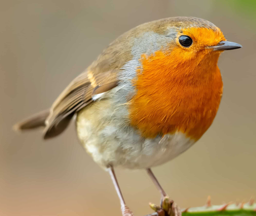

In [35]:
from fastai.vision.all import *

path = Path('dataset/bird_photos')
image_file = get_image_files(path)[0]
img = PILImage.create(image_file)
img.to_thumb(256, 256)

In [36]:
searches = 'forest', 'bird'
path = Path('dataset/bird_or_not')

if not path.exists():
    for o in searches:
        dest = (path/o)
        crawler = BingImageCrawler(storage={'root_dir' : str(dest)})
        crawler.crawl(keyword=f'{o} photo', max_num = 200)
        resize_images(dest, max_size=400, dest=dest)

2026-08-28 16:11:46,712 - INFO - icrawler.crawler - start crawling...
2026-08-28 16:11:46,713 - INFO - icrawler.crawler - starting 1 feeder threads...
2026-08-28 16:11:46,715 - INFO - icrawler.crawler - starting 1 parser threads...
2026-08-28 16:11:46,718 - INFO - icrawler.crawler - starting 1 downloader threads...
2026-08-28 16:11:47,074 - INFO - parser - downloaded image reached max num, thread parser-001 is ready to exit
2026-08-28 16:11:47,075 - INFO - parser - thread parser-001 exit
2026-08-28 16:11:47,429 - INFO - parser - parsing result page https://www.bing.com/images/async?q=forest photo&first=0
2026-08-28 16:11:50,263 - INFO - downloader - image #1	https://access-ci.org/wp-content/uploads/2024/09/boreal-forest.jpg
2026-08-28 16:11:51,255 - INFO - downloader - image #2	https://wildlifeinformer.com/wp-content/uploads/2023/04/boreal-forest.jpg
2026-08-28 16:11:52,956 - INFO - downloader - image #3	https://wildlifeinformer.com/wp-content/uploads/2023/04/tropical-rainforest-in-tha

In [37]:
failed = verify_images(get_image_files(path))
failed.map(Path.unlink)

[]

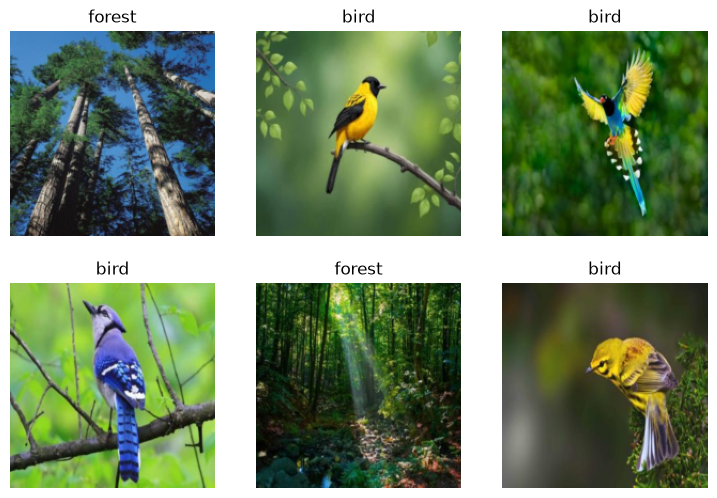

In [41]:
dls = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_items=get_image_files,
    splitter=RandomSplitter(valid_pct=0.2, seed=42),
    get_y=parent_label,
    item_tfms=[Resize(192, method='squish')]
).dataloaders(path, bs=6)

dls.show_batch(max_n = 6)

In [42]:
learn = cnn_learner(dls, resnet18, metrics=error_rate)
learn.fine_tune(3)

d:\Engineering\Technology\AI\FastAI\.venv\Lib\site-packages\fastai\vision\learner.py:304: UserWarning: `cnn_learner` has been renamed to `vision_learner` -- please update your code
  warn("`cnn_learner` has been renamed to `vision_learner` -- please update your code")


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\AMR/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [03:34<00:00, 218kB/s] 


epoch,train_loss,valid_loss,error_rate,time
0,0.993016,0.296299,0.200000,00:02


epoch,train_loss,valid_loss,error_rate,time
0,0.385755,0.013959,0.000000,00:01
1,0.322914,0.000499,0.000000,00:01
2,0.426884,0.001472,0.000000,00:01


In [47]:
is_bird,_, probability = learn.predict(PILImage.create('dataset/bird_photos/000001.jpg'))
print(f'this is a: {is_bird}.')
print(f'probability its a bird: {probability[0]:.4f}')

<div><progress max="1" value="0"></progress> 0.00% [0/1 00:00&lt;?]</div>

this is a: bird.
probability its a bird: 0.9940
